--- Результати інтерполяції ---
Вузли x: [0.  0.2 0.4]
Значення f(x_i): [5.0, 5.397, 5.779]
Коефіцієнти багаточлена Лагранжа: 
        2
-0.198 x + 2.026 x + 5
Точне значення f(0.3): 5.591
Інтерпольоване значення L_2(0.3): 5.59
Теоретична оцінка похибки: 0.001
Реальна похибка у точці x=0.3: 0.0009727


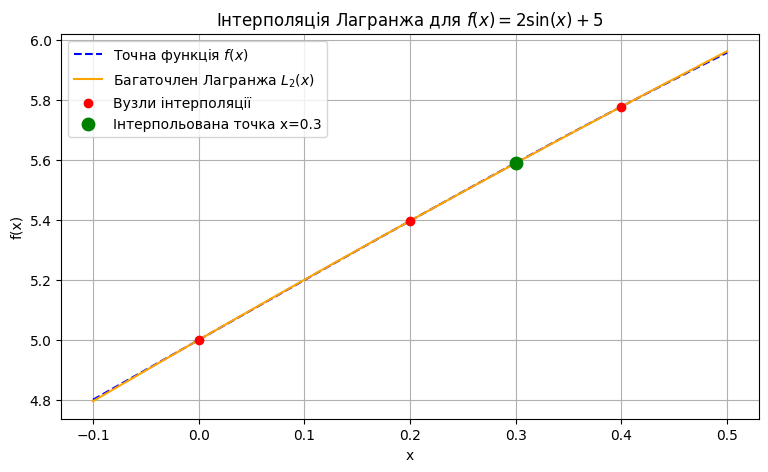

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
import math

# 1. Визначення глобальних параметрів
beta_1 = 0
beta_2 = 4
alpha_1 = beta_1 + 1.0
alpha_2 = beta_2 + 1.0

def f(x):
    return (1 + alpha_1) * np.sin(x) + alpha_2

# 2. Вузли інтерполяції та точні значення функції
x_nodes = np.array([0.0, 0.2, 0.4])
y_nodes = f(x_nodes)

# Цільова точка для обчислення
x_target = 0.3

# 3. Побудова інтерполяційного багаточлена Лагранжа
poly = lagrange(x_nodes, y_nodes)

# 4. Обчислення значень у точці x = 0.3
y_target_exact = f(x_target)
y_target_interp = poly(x_target)

# 5. Оцінка похибки
# Третя похідна f'''(x) дорівнює -2*cos(x). Максимум модуля на [0, 0.4] знаходиться в x=0
max_deriv3 = np.max(np.abs(-2 * np.cos(np.linspace(0, 0.4, 100))))
omega_2 = np.abs(np.prod(x_target - x_nodes))

theoretical_error = (max_deriv3 / math.factorial(3)) * omega_2
actual_error = np.abs(y_target_exact - y_target_interp)

# Виведення результатів зі збереженням 4 значущих цифр
print("--- Результати інтерполяції ---")
print(f"Вузли x: {x_nodes}")
print(f"Значення f(x_i): {[float(f'{val:.4g}') for val in y_nodes]}")
print(f"Коефіцієнти багаточлена Лагранжа: \n{poly}")
print(f"Точне значення f(0.3): {y_target_exact:.4g}")
print(f"Інтерпольоване значення L_2(0.3): {y_target_interp:.4g}")
print(f"Теоретична оцінка похибки: {theoretical_error:.4g}")
print(f"Реальна похибка у точці x=0.3: {actual_error:.4g}")

# 6. Побудова графіка
x_plot = np.linspace(-0.1, 0.5, 200)
plt.figure(figsize=(9, 5))
plt.plot(x_plot, f(x_plot), label='Точна функція $f(x)$', linestyle='dashed', color='blue')
plt.plot(x_plot, poly(x_plot), label='Багаточлен Лагранжа $L_2(x)$', color='orange')
plt.scatter(x_nodes, y_nodes, color='red', zorder=5, label='Вузли інтерполяції')
plt.scatter(x_target, y_target_interp, color='green', zorder=5, s=80, label='Інтерпольована точка x=0.3')

plt.title('Інтерполяція Лагранжа для $f(x) = 2\\sin(x) + 5$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

--- Таблиця поділених різниць ---
-1	-0.3	1.8	-1.15	0.6333
0	1.5	-0.5	0.75
1	1	1
2	2

Коефіцієнти багаточлена Ньютона: [-0.3, 1.8, -1.15, 0.6333]

--- Перевірка багаточлена у вузлах ---
x =    -1 | Точне f(x) =  -0.3 | Ньютон L_3(x) =  -0.3
x =     0 | Точне f(x) =   1.5 | Ньютон L_3(x) =   1.5
x =     1 | Точне f(x) =     1 | Ньютон L_3(x) =     1
x =     2 | Точне f(x) =     2 | Ньютон L_3(x) =     2


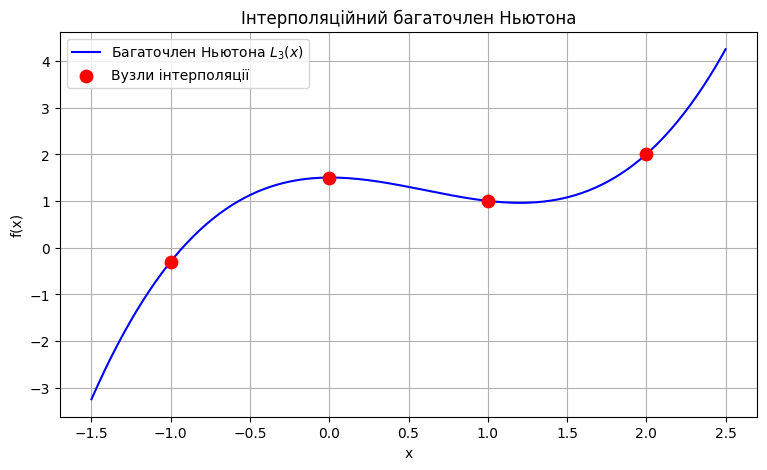

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Визначення глобальних параметрів та вхідних даних
alpha_1 = 1.0
alpha_2 = 5.0

x_nodes = np.array([-1.0, 0.0, 1.0, 2.0])
y_nodes = np.array([-3.0 * alpha_1 / 10.0, 1.5, 2.0 * alpha_2 / 10.0, 4.0 * alpha_2 / 10.0])

# 2. Функція для обчислення таблиці поділених різниць
def divided_diff(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
    return coef

div_diff_table = divided_diff(x_nodes, y_nodes)

# Коефіцієнти багаточлена Ньютона знаходяться у першому рядку таблиці
newton_coeffs = div_diff_table[0, :]

print("--- Таблиця поділених різниць ---")
for i in range(len(x_nodes)):
    row = [f"{x_nodes[i]:.4g}"] + [f"{div_diff_table[i][j]:.4g}" if div_diff_table[i][j] != 0 or j==0 else "" for j in range(len(x_nodes) - i)]
    print("\t".join(row))

print(f"\nКоефіцієнти багаточлена Ньютона: {[float(f'{val:.4g}') for val in newton_coeffs]}")

# 3. Функція для обчислення значення багаточлена Ньютона у заданій точці
def newton_poly(coef, x_data, x):
    n = len(x_data) - 1 
    p = coef[n]
    for k in range(1, n + 1):
        p = coef[n - k] + (x - x_data[n - k]) * p
    return p

# 4. Перевірка результатів: обчислення у вузлах
print("\n--- Перевірка багаточлена у вузлах ---")
for xi, yi in zip(x_nodes, y_nodes):
    y_calc = newton_poly(newton_coeffs, x_nodes, xi)
    print(f"x = {xi:5.4g} | Точне f(x) = {yi:5.4g} | Ньютон L_3(x) = {y_calc:5.4g}")

# 5. Побудова графіка
x_plot = np.linspace(-1.5, 2.5, 200)
y_plot = newton_poly(newton_coeffs, x_nodes, x_plot)

plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_plot, label='Багаточлен Ньютона $L_3(x)$', color='blue')
plt.scatter(x_nodes, y_nodes, color='red', s=80, zorder=5, label='Вузли інтерполяції')

plt.title('Інтерполяційний багаточлен Ньютона')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

--- Таблиця узагальнених поділених різниць ---
-1	-0.3				
0	0.75	1.05			
0	0.75	0.5	-0.55		
0	0.75	0.5	0.125	0.675	
1	0.2	-0.55	-1.05	-1.175	-0.925

Коефіцієнти багаточлена Ерміта: [-0.3, 1.05, -0.55, 0.675, -0.925]

--- Перевірка багаточлена у вузлах ---
x = -1.0 | Точне f(-1) =    -0.3 | H_4(-1) =    -0.3
x =  0.0 | Точне f(0)  =    0.75 | H_4(0)  =    0.75
x =  1.0 | Точне f(1)  =     0.2 | H_4(1)  =     0.2


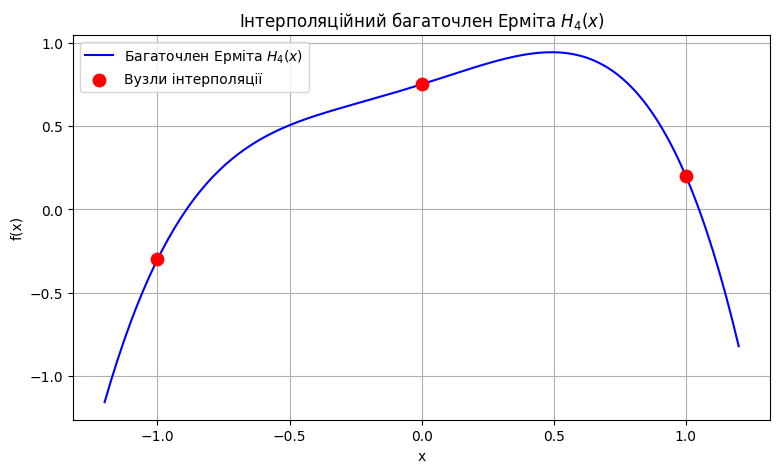

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Вхідні дані
alpha_1 = 1.0
alpha_2 = 5.0

# Розширений масив вузлів (з урахуванням кратності)
z_nodes = np.array([-1.0, 0.0, 0.0, 0.0, 1.0])

# Значення функції та її похідних у відповідних точках
f_minus1 = -3.0 * alpha_1 / 10.0
f_0 = 1.5 * alpha_2 / 10.0
f_1 = 2.0 * alpha_1 / 10.0
df_0 = 0.5
d2f_0 = 0.25

# 2. Побудова таблиці узагальнених поділених різниць
n = len(z_nodes)
div_diff = np.zeros((n, n))

# Заповнюємо нульовий стовпець (значення функції)
y_vals = [f_minus1, f_0, f_0, f_0, f_1]
for i in range(n):
    div_diff[i, 0] = y_vals[i]

# Обчислюємо поділені різниці алгоритмічно
for j in range(1, n):
    for i in range(j, n):
        # Якщо вузли збігаються - використовуємо похідні
        if z_nodes[i] == z_nodes[i - j]:
            if j == 1:
                div_diff[i, j] = df_0
            elif j == 2:
                div_diff[i, j] = d2f_0 / math.factorial(2)
        # Якщо вузли різні - стандартна формула
        else:
            div_diff[i, j] = (div_diff[i, j - 1] - div_diff[i - 1, j - 1]) / (z_nodes[i] - z_nodes[i - j])

# Коефіцієнти багаточлена Ерміта (головна діагональ матриці)
hermite_coeffs = [div_diff[i, i] for i in range(n)]

print("--- Таблиця узагальнених поділених різниць ---")
for i in range(n):
    row = [f"{z_nodes[i]:.4g}"] + [f"{div_diff[i, j]:.4g}" if j <= i else "" for j in range(n)]
    print("\t".join(row))

print(f"\nКоефіцієнти багаточлена Ерміта: {[float(f'{val:.4g}') for val in hermite_coeffs]}")

# 3. Функція обчислення значення багаточлена Ерміта
def hermite_poly(x, z, coeffs):
    res = 0.0
    for i in range(len(coeffs)):
        term = coeffs[i]
        for j in range(i):
            term *= (x - z[j])
        res += term
    return res

# 4. Перевірка результатів у вузлах
print("\n--- Перевірка багаточлена у вузлах ---")
print(f"x = -1.0 | Точне f(-1) = {f_minus1:7.4g} | H_4(-1) = {hermite_poly(-1.0, z_nodes, hermite_coeffs):7.4g}")
print(f"x =  0.0 | Точне f(0)  = {f_0:7.4g} | H_4(0)  = {hermite_poly(0.0, z_nodes, hermite_coeffs):7.4g}")
print(f"x =  1.0 | Точне f(1)  = {f_1:7.4g} | H_4(1)  = {hermite_poly(1.0, z_nodes, hermite_coeffs):7.4g}")

# 5. Побудова графіка
x_plot = np.linspace(-1.2, 1.2, 200)
y_plot = [hermite_poly(xi, z_nodes, hermite_coeffs) for xi in x_plot]

plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_plot, label='Багаточлен Ерміта $H_4(x)$', color='blue')

# Відображення вузлів
unique_nodes = [-1.0, 0.0, 1.0]
unique_vals = [f_minus1, f_0, f_1]
plt.scatter(unique_nodes, unique_vals, color='red', s=80, zorder=5, label='Вузли інтерполяції')

plt.title('Інтерполяційний багаточлен Ерміта $H_4(x)$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

--- Таблиця скінченних різниць ---
x_i	f(x_i)	Δ^1f_i	Δ^2f_i	Δ^3f_i
-1	-0.3	1.05	-1.6	2.35
0	0.75	-0.55	0.75	
1	0.2	0.2		
2	0.4			

--- Перевірка багаточленів у вузлах ---
x =    -1 | f(x) точне =  -0.3 | Вперед =  -0.3 | Назад =  -0.3
x =     0 | f(x) точне =  0.75 | Вперед =  0.75 | Назад =  0.75
x =     1 | f(x) точне =   0.2 | Вперед =   0.2 | Назад =   0.2
x =     2 | f(x) точне =   0.4 | Вперед =   0.4 | Назад =   0.4


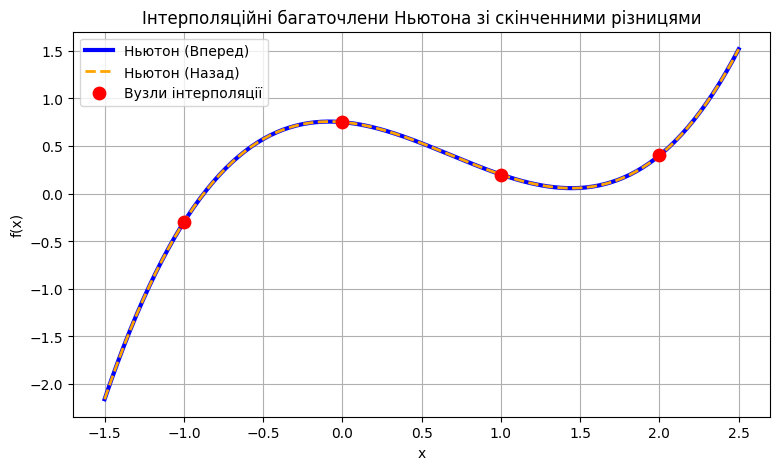

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Вхідні дані
alpha_1 = 1.0
alpha_2 = 5.0
h = 1.0

x_nodes = np.array([-1.0, 0.0, 1.0, 2.0])
y_nodes = np.array([-3.0 * alpha_1 / 10.0, 1.5 * alpha_2 / 10.0, 
                    2.0 * alpha_1 / 10.0, 4.0 * alpha_1 / 10.0])

n = len(x_nodes)

# 2. Обчислення таблиці скінченних різниць
# Матриця для зберігання скінченних різниць. Перший стовпець - це значення y_nodes
fin_diff = np.zeros((n, n))
fin_diff[:, 0] = y_nodes

for j in range(1, n):
    for i in range(n - j):
        fin_diff[i, j] = fin_diff[i + 1, j - 1] - fin_diff[i, j - 1]

# Виведення таблиці скінченних різниць
print("--- Таблиця скінченних різниць ---")
header = ["x_i", "f(x_i)"] + [f"Δ^{j}f_i" for j in range(1, n)]
print("\t".join(header))
for i in range(n):
    row = [f"{x_nodes[i]:.4g}"] + [f"{fin_diff[i, j]:.4g}" if j <= n - 1 - i else "" for j in range(n)]
    print("\t".join(row))

# 3. Формула Ньютона для інтерполювання ВПЕРЕД
def newton_forward(x, x_nodes, diff_table, h):
    # Виправлено: беремо лише x_nodes[0]
    t = (x - x_nodes[0]) / h
    # Виправлено: беремо початкове значення diff_table[0, 0]
    res = diff_table[0, 0]
    t_term = 1.0
    for i in range(1, len(x_nodes)):
        t_term *= (t - i + 1)
        res += (diff_table[0, i] / math.factorial(i)) * t_term
    return res

# 4. Формула Ньютона для інтерполювання НАЗАД
def newton_backward(x, x_nodes, diff_table, h):
    n = len(x_nodes) - 1
    t = (x - x_nodes[-1]) / h
    res = diff_table[n, 0]
    t_term = 1.0
    for i in range(1, len(x_nodes)):
        t_term *= (t + i - 1)
        res += (diff_table[n - i, i] / math.factorial(i)) * t_term
    return res

# 5. Перевірка та візуалізація
print("\n--- Перевірка багаточленів у вузлах ---")
for xi, yi in zip(x_nodes, y_nodes):
    y_fwd = newton_forward(xi, x_nodes, fin_diff, h)
    y_bwd = newton_backward(xi, x_nodes, fin_diff, h)
    print(f"x = {xi:5.4g} | f(x) точне = {yi:5.4g} | Вперед = {y_fwd:5.4g} | Назад = {y_bwd:5.4g}")

x_plot = np.linspace(-1.5, 2.5, 200)
y_fwd_plot = [newton_forward(x, x_nodes, fin_diff, h) for x in x_plot]
y_bwd_plot = [newton_backward(x, x_nodes, fin_diff, h) for x in x_plot]

plt.figure(figsize=(9, 5))
# Якщо графіки збігаються, лінія "назад" буде накладатися на пунктирну лінію "вперед"
plt.plot(x_plot, y_fwd_plot, label='Ньютон (Вперед)', color='blue', linewidth=3)
plt.plot(x_plot, y_bwd_plot, label='Ньютон (Назад)', color='orange', linestyle='dashed', linewidth=2)
plt.scatter(x_nodes, y_nodes, color='red', s=80, zorder=5, label='Вузли інтерполяції')

plt.title('Інтерполяційні багаточлени Ньютона зі скінченними різницями')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
import numpy as np

# Глобальні параметри згідно з варіантом
alpha_1 = 1.0
alpha_2 = 5.0

# Тестова функція: f(x) = (1 + alpha_1)*sin(x) + alpha_2
def f(x):
    return (1 + alpha_1) * np.sin(x) + alpha_2

# Точна похідна для перевірки: f'(x) = (1 + alpha_1)*cos(x)
def df_exact(x):
    return (1 + alpha_1) * np.cos(x)

# Третя похідна f'''(x) = -(1 + alpha_1)*cos(x) для оцінки теоретичної похибки
def d3f_exact(x):
    return -(1 + alpha_1) * np.cos(x)

# Функція чисельного диференціювання
def numerical_differentiation(x0, h):
    x1 = x0 + h
    x2 = x1 + h
    
    # Проміжні обчислення з утриманням 4 значущих цифр
    f0 = float(f"{f(x0):.4g}")
    f1 = float(f"{f(x1):.4g}")
    f2 = float(f"{f(x2):.4g}")
    
    print(f"Значення функції (4 значущі цифри):")
    print(f"f(x0) = {f0:.4g}")
    print(f"f(x1) = {f1:.4g}")
    print(f"f(x2) = {f2:.4g}\n")
    
    # Обчислення для f'(x0)
    num_x0 = float(f"{-3*f0 + 4*f1 - f2:.4g}")
    df_x0 = float(f"{num_x0 / (2*h):.4g}")
    
    # Обчислення для f'(x1)
    num_x1 = float(f"{f2 - f0:.4g}")
    df_x1 = float(f"{num_x1 / (2*h):.4g}")
    
    return df_x0, df_x1, x1

# Вхідні дані
x0 = 0.0
h = 0.2
x2 = x0 + 2 * h  # Кінцева точка відрізка для оцінки похибки

# Розрахунок та вивід
df_x0_num, df_x1_num, x1 = numerical_differentiation(x0, h)

print("Результати диференціювання:")
print(f"Чисельне f'(x0): {df_x0_num:.4g} (Точне: {df_exact(x0):.4g})")
print(f"Чисельне f'(x1): {df_x1_num:.4g} (Точне: {df_exact(x1):.4g})\n")

# Обчислення реальної похибки
print("Абсолютна похибка формул (фактична):")
print(f"Похибка у x0: {abs(df_x0_num - df_exact(x0)):.4g}")
print(f"Похибка у x1: {abs(df_x1_num - df_exact(x1)):.4g}\n")

# --- ДОДАНИЙ БЛОК: Теоретична похибка ---
# Знаходимо максимум модуля 3-ї похідної на відрізку [x0, x2]
x_vals = np.linspace(x0, x2, 100)
M3 = np.max(np.abs(d3f_exact(x_vals)))

# Формули залишкового члена:
theoretical_error_x0 = (h**2 / 3) * M3  # Для f'(x0)
theoretical_error_x1 = (h**2 / 6) * M3  # Для f'(x1) (центральна різниця)

print("Теоретична похибка (залишковий член):")
print(f"M_3 (максимум |f'''(x)| на [{x0}, {x2}]): {M3:.4g}")
print(f"Теоретична похибка у x0 (R_0): {theoretical_error_x0:.4g}")
print(f"Теоретична похибка у x1 (R_1): {theoretical_error_x1:.4g}")

Значення функції (4 значущі цифри):
f(x0) = 5
f(x1) = 5.397
f(x2) = 5.779

Результати диференціювання:
Чисельне f'(x0): 2.022 (Точне: 2)
Чисельне f'(x1): 1.948 (Точне: 1.96)

Абсолютна похибка формул (фактична):
Похибка у x0: 0.022
Похибка у x1: 0.01213

Теоретична похибка (залишковий член):
M_3 (максимум |f'''(x)| на [0.0, 0.4]): 2
Теоретична похибка у x0 (R_0): 0.02667
Теоретична похибка у x1 (R_1): 0.01333


Моменти M_i (другі похідні) у вузлах:
M_0 = 0
M_1 = -0.5625
M_2 = 2.22e-15

Коефіцієнти кубічного сплайна на інтервалах [0.0, 0.2] та [0.2, 0.4]:
При (x-x_i)^3 (D/6): [-0.4688, 0.4688]
При (x-x_i)^2 (C/2): [0.0, -0.2813]
При (x-x_i)^1 (B):   [2.004, 1.947]
При (x-x_i)^0 (A):   [5.0, 5.397]


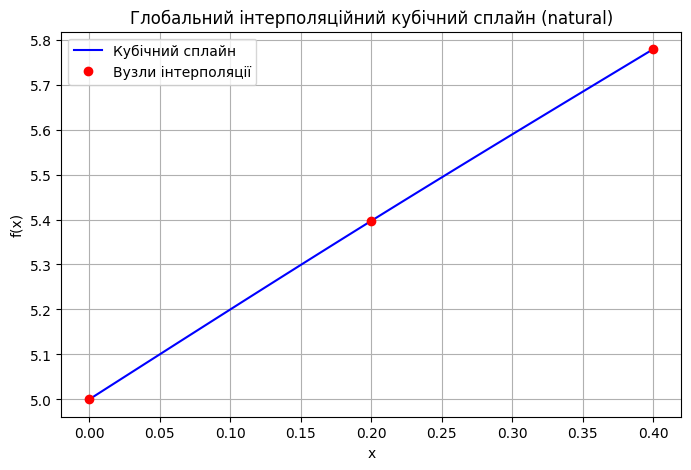

In [18]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# 1. Задання фіктивних даних (3 вузли) з утриманням 4 значущих цифр
x_nodes = np.array([0.0, 0.2, 0.4])
y_nodes = np.array([5.000, 5.397, 5.779])

# 2. Побудова кубічного сплайна з природними крайовими умовами
# bc_type='natural' забезпечує умови M_0 = 0 та M_2 = 0
cs = CubicSpline(x_nodes, y_nodes, bc_type='natural')

# 3. Обчислення та вивід других похідних (моментів M_i)
moments = [cs(x, 2) for x in x_nodes]
print("Моменти M_i (другі похідні) у вузлах:")
# Виправлено: додано індекс [0] для moments
print(f"M_0 = {moments[0]:.4g}")
print(f"M_1 = {moments[1]:.4g}")
print(f"M_2 = {moments[2]:.4g}\n")

# 4. Вивід коефіцієнтів поліномів на кожному інтервалі
# Матриця cs.c містить коефіцієнти при: (x-x_i)^3, (x-x_i)^2, (x-x_i)^1, (x-x_i)^0
# Виправлено: правильна 2D-індексація матриці cs.c (рядок - степінь, стовпець - номер інтервалу)
print("Коефіцієнти кубічного сплайна на інтервалах [0.0, 0.2] та [0.2, 0.4]:")
print(f"При (x-x_i)^3 (D/6): [{float(f'{cs.c[0, 0]:.4g}')}, {float(f'{cs.c[0, 1]:.4g}')}]")
print(f"При (x-x_i)^2 (C/2): [{float(f'{cs.c[1, 0]:.4g}')}, {float(f'{cs.c[1, 1]:.4g}')}]")
print(f"При (x-x_i)^1 (B):   [{float(f'{cs.c[2, 0]:.4g}')}, {float(f'{cs.c[2, 1]:.4g}')}]")
print(f"При (x-x_i)^0 (A):   [{float(f'{cs.c[3, 0]:.4g}')}, {float(f'{cs.c[3, 1]:.4g}')}]")

# 5. Побудова графіка
x_dense = np.linspace(0.0, 0.4, 100)
y_dense = cs(x_dense)

plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_dense, label='Кубічний сплайн', color='blue')
plt.plot(x_nodes, y_nodes, 'ro', label='Вузли інтерполяції')
plt.title("Глобальний інтерполяційний кубічний сплайн (natural)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

Матриця нормальних рівнянь A (4 значущі цифри):
[[3.142 4.935 10.34]
 [4.935 10.34 24.35]
 [10.34 24.35 61.2]]

Вектор правих частин b (4 значущі цифри):
[2 4 9.133]

Коефіцієнти апроксимуючого багаточлена c_0, c_1, c_2:
c_0 = -0.02432
c_1 = 0.5979
c_2 = -0.08456


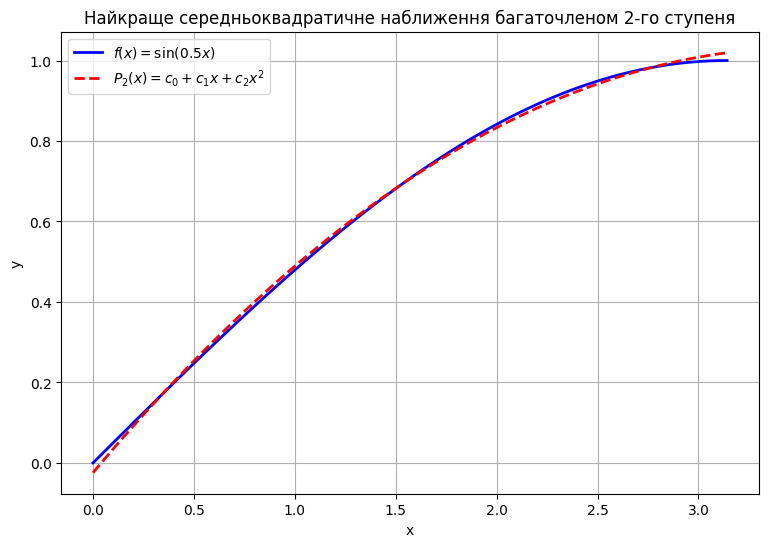

In [20]:
import numpy as np
import scipy.integrate as spi
import matplotlib.pyplot as plt

# 1. Глобальні параметри та цільова функція
alpha_1 = 1.0
alpha_2 = 5.0

def f(x):
    return alpha_1 * np.sin(alpha_2 * x / 10.0)

# 2. Формування матриці A (СЛАР: A * c = b)
A = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        A[i, j] = (np.pi**(i + j + 1)) / (i + j + 1)

# 3. Формування вектора b за допомогою scipy.integrate
b = np.zeros(3)
for j in range(3):
    # Інтегруємо f(x) * x^j на проміжку [0, pi]
    integral_val, _ = spi.quad(lambda x: f(x) * (x**j), 0, np.pi)
    b[j] = integral_val

# 4. Розв'язання системи рівнянь для знаходження коефіцієнтів багаточлена
c = np.linalg.solve(A, b)

# Виведення системи рівнянь та результатів з 4 значущими цифрами
print("Матриця нормальних рівнянь A (4 значущі цифри):")
print(np.array2string(A, formatter={'float_kind':lambda x: f"{float(f'{x:.4g}'):.4g}"}))
print("\nВектор правих частин b (4 значущі цифри):")
print(np.array2string(b, formatter={'float_kind':lambda x: f"{float(f'{x:.4g}'):.4g}"}))

print("\nКоефіцієнти апроксимуючого багаточлена c_0, c_1, c_2:")
for i, coef in enumerate(c):
    print(f"c_{i} = {float(f'{coef:.4g}'):.4g}")

# 5. Побудова багаточлена P2(x)
def P2(x):
    # Виправлено: правильні індекси для коефіцієнтів c[0], c[1], c[2]
    return c[0] + c[1]*x + c[2]*(x**2)

# 6. Побудова графіків
x_vals = np.linspace(0, np.pi, 100)
y_f = f(x_vals)
y_P2 = P2(x_vals)

plt.figure(figsize=(9, 6))
plt.plot(x_vals, y_f, label=r'$f(x) = \sin(0.5x)$', color='blue', linewidth=2)
plt.plot(x_vals, y_P2, label=r'$P_2(x) = c_0 + c_1x + c_2x^2$', color='red', linestyle='--', linewidth=2)
plt.title('Найкраще середньоквадратичне наближення багаточленом 2-го ступеня')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Суми для нормальних рівнянь:
Σ x_i = 2
Σ x_i^2 = 6
Σ y_i = 4.2
Σ x_i*y_i = 5.3

Коефіцієнти лінійної апроксимації:
alpha_0 = 0.73
alpha_1 = 0.64

Знайдена лінійна апроксимація: y = 0.73 + 0.64 * x


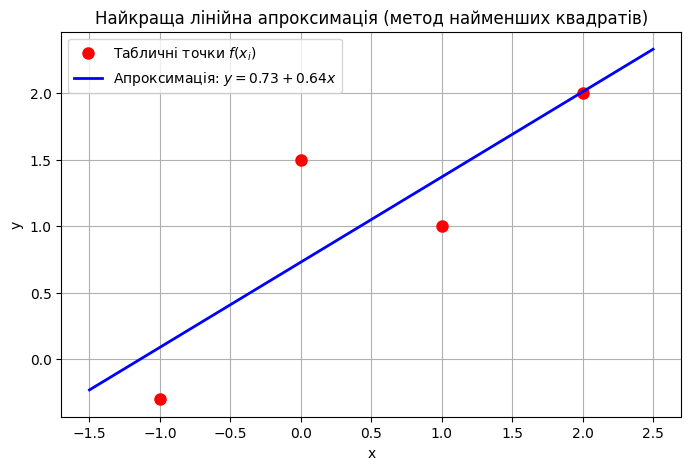

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Вхідні дані згідно з варіантом (alpha_1 = 1, alpha_2 = 5)
alpha_1 = 1.0
alpha_2 = 5.0

x = np.array([-1.0, 0.0, 1.0, 2.0])
y = np.array([
    -3.0 * alpha_1 / 10.0, 
    1.5, 
    2.0 * alpha_2 / 10.0, 
    4.0 * alpha_2 / 10.0
])

# 2. Обчислення сум для нормальних рівнянь
n = len(x)
sum_x = np.sum(x)
sum_x2 = np.sum(x**2)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)

# 3. Формування матриці та вектора правої частини (A^T * A * z = A^T * b)
A = np.array([
    [n, sum_x], 
    [sum_x, sum_x2]
])
b = np.array([sum_y, sum_xy])

# 4. Розв'язання системи лінійних рівнянь
coeffs = np.linalg.solve(A, b)
alpha_0, alpha_1 = coeffs

# Вивід проміжних результатів із 4 значущими цифрами
print("Суми для нормальних рівнянь:")
print(f"Σ x_i = {sum_x:.4g}")
print(f"Σ x_i^2 = {sum_x2:.4g}")
print(f"Σ y_i = {sum_y:.4g}")
print(f"Σ x_i*y_i = {sum_xy:.4g}\n")

# Вивід коефіцієнтів
print("Коефіцієнти лінійної апроксимації:")
print(f"alpha_0 = {float(f'{alpha_0:.4g}'):.4g}")
print(f"alpha_1 = {float(f'{alpha_1:.4g}'):.4g}\n")

print(f"Знайдена лінійна апроксимація: y = {float(f'{alpha_0:.4g}'):.4g} + {float(f'{alpha_1:.4g}'):.4g} * x")

# 5. Побудова графіка
# Створення масиву x для побудови прямої
x_line = np.linspace(-1.5, 2.5, 100)
y_line = alpha_0 + alpha_1 * x_line

plt.figure(figsize=(8, 5))
# Дані з таблиці
plt.plot(x, y, 'ro', markersize=8, label='Табличні точки $f(x_i)$')
# Лінійна апроксимація
plt.plot(x_line, y_line, 'b-', linewidth=2, label=f'Апроксимація: $y = {alpha_0:.4g} + {alpha_1:.4g}x$')

plt.title("Найкраща лінійна апроксимація (метод найменших квадратів)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import numpy as np

# 1. Вхідні дані згідно з варіантом (alpha_1 = 1, alpha_2 = 5)
x = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
y = np.array([0.2000, 3.000, 2.000, 5.100, 3.000])

# Функція для форматування до 4 значущих цифр
def f4(val):
    return float(f"{val:.4g}")

# --- a) Метод правих прямокутників (порядок m=1) ---
# Крок h1 = 0.2 (праві точки інтервалів [0.1, 0.3] -> x=0.3 (y[2]), [0.3, 0.5] -> x=0.5 (y[4]))
S_right_02 = f4(0.2 * (y[2] + y[4]))

# Крок h2 = 0.1 (праві точки 4-х інтервалів: y[1], y[2], y[3], y[4])
S_right_01 = f4(0.1 * (y[1] + y[2] + y[3] + y[4]))

# Оцінка за Рунге
R_right = f4((S_right_01 - S_right_02) / (2**1 - 1))

# --- b) Метод середніх прямокутників (порядок m=2) ---
# Крок H1 = 0.4 (середина інтервалу [0.1, 0.5] -> x=0.3 (y[2]))
S_mid_04 = f4(0.4 * y[2])

# Крок H2 = 0.2 (середини інтервалів [0.1, 0.3] -> x=0.2 (y[1]) та [0.3, 0.5] -> x=0.4 (y[3]))
S_mid_02 = f4(0.2 * (y[1] + y[3]))

# Оцінка за Рунге
R_mid = f4((S_mid_02 - S_mid_04) / (2**2 - 1))

# --- c) Метод Сімпсона (порядок m=4) ---
# Крок H1 = 0.4 (інтервал [0.1, 0.5]) -> Simpson: (H/6)*(y_start + 4*y_mid + y_end)
S_simp_04 = f4((0.4 / 6.0) * (y[0] + 4*y[2] + y[4]))

# Крок H2 = 0.2 (складена формула: y_0 + 4*y_1 + 2*y_2 + 4*y_3 + y_4)
S_simp_02 = f4((0.2 / 6.0) * (y[0] + 4*y[1] + 2*y[2] + 4*y[3] + y[4]))

# Оцінка за Рунге
R_simp = f4((S_simp_02 - S_simp_04) / (2**4 - 1))

# --- Вивід результатів ---
print("Табличні значення:")
for xi, yi in zip(x, y):
    print(f"x = {xi:.1f}, y = {yi:.4g}")

print("\n--- a) Метод правих прямокутників ---")
print(f"S(h=0.2): {S_right_02:.4g}")
print(f"S(h=0.1): {S_right_01:.4g}")
print(f"Оцінка похибки Рунге: {R_right:.4g}")

print("\n--- b) Метод середніх прямокутників ---")
print(f"S(H=0.4): {S_mid_04:.4g}")
print(f"S(H=0.2): {S_mid_02:.4g}")
print(f"Оцінка похибки Рунге: {R_mid:.4g}")

print("\n--- c) Метод Сімпсона ---")
print(f"S(H=0.4): {S_simp_04:.4g}")
print(f"S(H=0.2): {S_simp_02:.4g}")
print(f"Оцінка похибки Рунге: {R_simp:.4g}")

Табличні значення:
x = 0.1, y = 0.2
x = 0.2, y = 3
x = 0.3, y = 2
x = 0.4, y = 5.1
x = 0.5, y = 3

--- a) Метод правих прямокутників ---
S(h=0.2): 1
S(h=0.1): 1.31
Оцінка похибки Рунге: 0.31

--- b) Метод середніх прямокутників ---
S(H=0.4): 0.8
S(H=0.2): 1.62
Оцінка похибки Рунге: 0.2733

--- c) Метод Сімпсона ---
S(H=0.4): 0.7467
S(H=0.2): 1.32
Оцінка похибки Рунге: 0.03822
